In [3]:
import torch 
import numpy as np 
import h5py
import os
from pathlib import Path
import importlib
import src.spatial_attn_lightning as binaural_lightning 
import yaml
from pytorch_lightning import Trainer, seed_everything

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# torch.set_float32_matmul_precision('medium')
# torch.backends.cuda.matmul.allow_tf32 = True
# torch.backends.cudnn.allow_tf32 = True
from corpus.speech_and_texture_test import SpeechAndTextureTestSet

import src.audio_transforms as at 
from IPython.display import display, Audio


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [4]:

config_path = "config/binaural_attn/word_task_v10_main_feature_gain_config.yaml"
# config_path = "config/binaural_attn/word_task_half_co_loc_v06.yaml"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

config['num_workers'] = 0
config['hparas']['batch_size'] = 10
config['audio']['rep_kwargs']['rep_on_gpu'] = True
print(f"Default lr is {config['hparas']['lr']}")
# config['hparas']['lr'] = 0.0001
# print(f"Trying lr = {config['hparas']['lr']}")



Default lr is 5e-06


In [5]:
# ## func to init layers with he initialization 
# def kaiming_init(model, mode='fan_in', init_type='normal'):
#     if init_type=='normal':
#         init_fn = torch.nn.init.kaiming_normal_
#     elif init_type=='uniform':
#         init_fn = torch.nn.init.kaiming_uniform_

#     for name, param in model.named_parameters():
#         if 'attn' in name:
#             continue
#         if name.endswith(".bias"):
#             # print(f"zero init {name}")
#             param.data.fill_(0)
#         elif any( part in name for part in ['conv', 'fullyconnected']):
#             # print(f"kaiming init {name}")
#             init_fn(param, mode=mode, nonlinearity='relu')



In [6]:
seed_everything(0)
importlib.reload(binaural_lightning)
module = binaural_lightning.BinauralAttentionModule(config)

Global seed set to 0


Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: True
coch_affine: True
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [5]:
# kaiming_init(module, mode='fan_in', init_type='uniform')

In [6]:
batch_size = config['hparas']['batch_size']

batch = torch.arange(batch_size)
p = torch.tensor([1/batch_size] * batch_size)
index = p.multinomial(num_samples=int(0.1 * batch_size), replacement=False)

In [7]:
batch[index]

tensor([10, 11])

In [8]:
seed_everything(0)
trainer = Trainer(
    precision="32",
    limit_val_batches=0.0,
    num_nodes=1,
    # benchmark=True,
    devices=1, # was gpus=1,
    # detect_anomaly=True,
    # strategy="ddp_notebook",
    accelerator="gpu",
)
trainer.fit(module)

[rank: 0] Seed set to 0
/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /om2/user/imgriff/conda_envs/pytorch_2/lib/python3.1 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/pytorch_lightning/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                         | Params
------------------------------------------------------------------
0 | audio_transforms | AudioCompose                 | 0     
1 | model           

Using v06 dataset
/om/scratch/Sun/imgriff/datasets/spatial_audio_pipeline/assets/dataset_binaural_attn/v08
Using 0.1 cue free data
Using gender balanced training 4M set
cue type: mixed
mixture_percentages={'voice_only': 0.5, 'voice_and_location': 0.5}
913 files in train concat dataset


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=1` in the `DataLoader` to improve performance.


len training set = 151558
Epoch 0:   0%|          | 0/151558 [00:00<?, ?it/s] 

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/pytorch_lightning/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


### Make sure de-mean doesn't alter signals 

In [7]:
## Check dataset 

dataset = module.dataset(**config['corpus'], mode='train', batch_size=config['hparas']['batch_size'])

Using v06 dataset
/om/scratch/Sun/imgriff/datasets/spatial_audio_pipeline/assets/dataset_binaural_attn/v10
Using 0.1 cue free data
Using gender balanced training 4M set


cue type: mixed
mixture_percentages={'voice_only': 0.5, 'voice_and_location': 0.5}
1224 files in train concat dataset


In [122]:
cue, target, distractor, labels = dataset[0]
target_eg = target[4]
distractor_eg = distractor[4]

In [123]:
left_m, right_m = target_eg.mean(-1)

In [124]:
left_pow, right_pow = np.sqrt(np.mean(np.power(target_eg, 2), axis=-1))
raw_lr_ratio = left_pow / right_pow
print(raw_lr_ratio)
# demean then re calc ratio 

target_demeaned_per_channel = target_eg - target_eg.mean(-1, keepdims=True) 
left_pow_pc, right_pow_pc = np.sqrt(np.mean(np.power(target_demeaned_per_channel, 2), axis=-1))
new_lr_ratio_pc = left_pow_pc / right_pow_pc
print(new_lr_ratio_pc)


# global demean 
target_global_dm = target_eg - target_eg.mean()
left_pow_gd, right_pow_gd = np.sqrt(np.mean(np.power(target_global_dm, 2), axis=-1))
new_lr_ratio_gd = left_pow_gd / right_pow_gd
print(new_lr_ratio_gd)


1.3956932
1.3956941
1.3956932


In [139]:
#### Simulate level shift then re calc ratio
left_pow, right_pow = np.sqrt(np.mean(np.power(target_eg, 2), axis=-1))
raw_lr_ratio = left_pow / right_pow
print(raw_lr_ratio)
# demean then re calc ratio 

set_to_65 = at.BinauralRMSNormalizeForegroundAndBackground(20e-6 * 10**(70/20), v2_demean=True)

scaled_target,_  = set_to_65(torch.from_numpy(target_eg), None)
scaled_target = scaled_target.numpy()
left_pow_scaled, right_pow_scaled = np.sqrt(np.mean(np.power(scaled_target, 2), axis=-1))
new_lr_ratio_scaled = left_pow_scaled / right_pow_scaled
print(new_lr_ratio_scaled)

1.3956932
1.395692


In [157]:
### 
# Get raw ratio

left_pow, right_pow = np.sqrt(np.mean(np.power(target_eg, 2), axis=-1))
raw_lr_ratio = left_pow / right_pow
print("Raw LR balance:\n\t", raw_lr_ratio)


### Test per ear level set 
rms_level = 20e-6 * 10**(60/20) # set to 60 in rms 


# demean
# this preserves level balance between ears 
target_global_dm = target_eg - target_eg.mean()
# compare using global vs per-ear rms 
global_rms = np.sqrt(np.mean(np.power(target_global_dm, 2)))
per_ear_rims = np.sqrt(np.mean(np.power(target_eg, 2), axis=-1))

# scale globally
global_normalized = target_global_dm * rms_level / global_rms
left_pow_gd, right_pow_gd = np.sqrt(np.mean(np.power(global_normalized, 2), axis=-1))
new_lr_ratio_gd = left_pow_gd / right_pow_gd
print("Global level set LR balance:\n\t", new_lr_ratio_gd)

# scale per-ear 
per_ear_normalized = target_global_dm * rms_level / per_ear_rims[:, None]
left_pow_pe, right_pow_pe = np.sqrt(np.mean(np.power(per_ear_normalized, 2), axis=-1))
new_lr_ratio_pe = left_pow_pe / right_pow_pe
print("Per-ear level set LR balance:\n\t", new_lr_ratio_pe)


Raw LR balance:
	 1.3956932
Global level set LR balance:
	 1.3956932
Per-ear level set LR balance:
	 0.99999684


In [ ]:
def demean_per_ear(x, ch_dim):
    """
    De-mean the input tensor per ear. 

    x: (batch, time, channels)
    ch_dim: channel dimension 

    return: (batch, time, channels)
    """
    return x - x.mean(dim=ch_dim, keepdim=True)

def rms_per_ear(x, ch_dim):
    """
    Calculate the RMS per ear. 

    x: (batch, time, channels)
    ch_dim: channel dimension 

    return: (batch, time)
    """
    return torch.sqrt((x ** 2).mean(dim=ch_dim))

    

def get_per_channel_pspectrum(signal, sr=44_100):
    power_per_ear = torch.fft.rfft(signal, dim=1).abs()
    db_per_ear = 20 * torch.log10(power_per_ear)
    # get freqs 
    samp_period = 1 / sr 
    n = signal.shape[1]
    freqs = torch.fft.rfftfreq(n, samp_period)
    return db_per_ear, freqs



class BinauralCombineWithRandomDBSNR(torch.nn.Module):
    """
    Takes two signals and combines them at a specified dB SNR level.
    Args:
        low_snr (float): the low end for the range of dB SNR to draw from
        high_snr (float): the high end for the range of db SNR to draw from
        rms_level (float): the end RMS value for the combined sound

    Returns:
        signal_in_noise, None

    """
    def __init__(self, low_snr=-10, high_snr=10, v2_demean=False):
        self.low_snr=low_snr
        self.high_snr=high_snr
        self.v2_demean = v2_demean
        super(BinauralCombineWithRandomDBSNR, self).__init__()

    def forward(self, foreground_wav, background_wav):
        """
        Args:
            foreground_wav (torch.Tensor): the waveform that will be used as
                the foreground audio sample (usually speech)
            background_wav (torch.Tensor): the waveform that will be used as
                the background audio sample
        """
        if self.low_snr == "clean" or self.high_snr == "clean":
            return foreground_wav, None
        if background_wav is None:
            return foreground_wav, None
        rand_db_snr = random.uniform(self.low_snr, self.high_snr)
        rms_ratio = np.power(10.0, rand_db_snr / 20.0)
        # Demean signal and noise before computing rms
        foreground_wav = ch_global_demean(foreground_wav, v2=self.v2_demean)
        background_wav = ch_global_demean(background_wav, v2=self.v2_demean)

        rms_foreground = ch_global_rms(foreground_wav)
        rms_background = ch_global_rms(background_wav)

        # Calculate the scale factor for the two sounds
        # TODO: filter out the signals that are only foreground or only background.
        # For now, to align with the jsinv3 dataset, we include the infinite SNR
        # cases
        if rms_foreground == 0: # No foreground condition (just noise)
            noise_scale_factor = 1
        elif rms_background == 0:
            noise_scale_factor = 0
        else:
            noise_scale_factor = torch.div(rms_foreground,
                                           torch.mul(rms_background,
                                                     rms_ratio))

        background_wav = torch.mul(noise_scale_factor, background_wav)
        signal_in_noise = torch.add(foreground_wav, background_wav)

        return signal_in_noise, None



In [80]:
target_eg.shape

(2, 110250)

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt


Per ear demean


Global signal demean


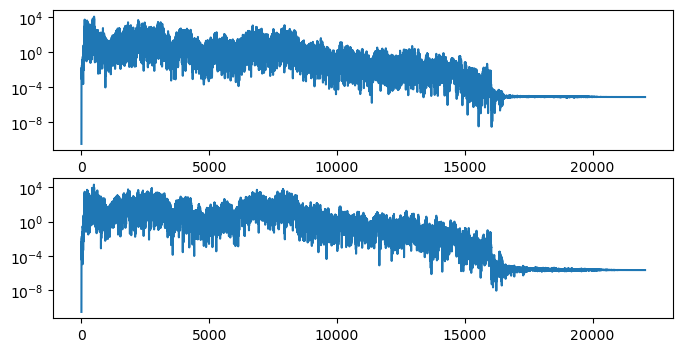

In [ ]:
tg = torch.from_numpy(target_eg).unsqueeze(0)
per_ear_dm_target = demean_per_ear(tg, ch_dim=-1).squeeze()
global_dm_target = at.ch_global_demean(tg, v2=True).squeeze()
print("Per ear demean")
display(Audio(per_ear_dm_target.squeeze(), rate=44100, normalize=False))
print("Global signal demean")
display(Audio(global_dm_target.squeeze(), rate=44100, normalize=False))
fig, axs = plt.subplots(2, 1, figsize=(8, 4))

# compute power spectra for each ear 
sr = 44_100
power_per_ear = torch.fft.rfft(per_ear_dm_target, dim=1).abs().pow(2)
# get freqs 
samp_period = 1 / sr 
n = per_ear_dm_target.shape[1]
freqs = torch.fft.rfftfreq(n, samp_period)
# plot power spectra
axs[0].semilogy(freqs, power_per_ear[0], label='Per ear left')
axs[1].semilogy(freqs, power_per_ear[1], label='Per ear right')

tensor(22050.)

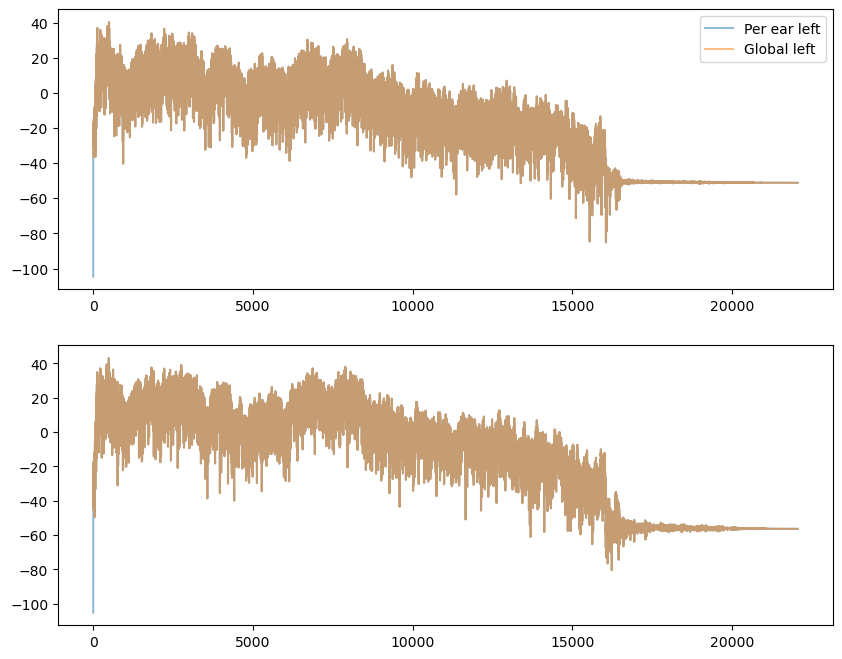

In [78]:
def compare_demean(signal, play_audio=False):
    tg = torch.from_numpy(signal).unsqueeze(0)
    per_ear_dm_target = demean_per_ear(tg, ch_dim=-1).squeeze()
    global_dm_target = at.ch_global_demean(tg, v2=True).squeeze()
    if play_audio:
        print("Per ear demean")
        display(Audio(per_ear_dm_target.squeeze(), rate=44100, normalize=False))
        print("Global signal demean")
        display(Audio(global_dm_target.squeeze(), rate=44100, normalize=False))

    fig, axs = plt.subplots(2, 1, figsize=(10,8))

    # compute power spectra for each ear 
    ppe_ps, freqs = get_per_channel_pspectrum(per_ear_dm_target)
    gdm_ps, _ = get_per_channel_pspectrum(global_dm_target)

    # plot power spectra
    axs[0].plot(freqs, ppe_ps[0], label='Per ear left', alpha=0.5)
    axs[0].plot(freqs, gdm_ps[0], label='Global left', alpha=0.5)
    axs[1].plot(freqs, ppe_ps[1], label='Per ear right', alpha=0.5)
    axs[1].plot(freqs, gdm_ps[1], label='Global right', alpha=0.5)

    axs[0].legend()


compare_demean(target_eg)


